In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")

In [2]:
input_dir = "convergence_results_final"
mcmc_main_swd = np.load(os.path.join(input_dir, "swd_obs.npy"))
mcmc_med_swd = np.load(os.path.join(input_dir, "swd_med.npy"))
mcmc_98_swd = np.load(os.path.join(input_dir, "swd_98.npy"))
base_swd = np.load(os.path.join(input_dir, "run_00", "base_swd_list.npy"))

mcmc_main_avg = (np.mean(mcmc_main_swd, axis=0) / base_swd[0])[:-6]
mcmc_med_avg = (np.mean(mcmc_med_swd, axis=0) / base_swd[1])[:-6]
mcmc_98_avg = (np.mean(mcmc_98_swd, axis=0) / base_swd[2])[:-6]
mcmc_main_std = (np.std(mcmc_main_swd / base_swd[0], axis=0))[:-6]
mcmc_med_std = (np.std(mcmc_med_swd / base_swd[1], axis=0))[:-6]
mcmc_98_std = (np.std(mcmc_98_swd / base_swd[2], axis=0))[:-6]

In [3]:
mcmc_main_avg

array([0.77817695, 0.72857549, 0.69413303, 0.55422267, 0.42632397,
       0.3442299 , 0.26991175, 0.25988724, 0.23556917, 0.14676362,
       0.11532838, 0.07744016, 0.08089053, 0.05311554, 0.04838707,
       0.03977821, 0.02986108])

In [4]:
pcn_main_swd = np.load(os.path.join(input_dir, "pcn_swd_obs_single.npy"))
pcn_main_swd

array([0.64885698, 0.64647206, 0.64055322, 0.6353333 , 0.63477221,
       0.63085687, 0.61433419, 0.598008  , 0.60229564, 0.60858042,
       0.60997221, 0.70637179, 0.76480414, 0.70651311, 0.68886239,
       0.66993902, 0.56996387, 0.53112043, 0.42392311, 0.34344785,
       0.30677938, 0.31232512, 0.33807362])

In [5]:
mcmc_main_pca = np.load(os.path.join(input_dir, "mcmc_swd_pca_obs.npy"))
mcmc_med_pca = np.load(os.path.join(input_dir, "mcmc_swd_pca_med.npy"))
mcmc_98_pca = np.load(os.path.join(input_dir, "mcmc_swd_pca_98.npy"))

In [6]:
ntrials = 10
nsamps = 23
si_swd = np.empty((ntrials, nsamps, 3))
for i in range(ntrials):
    si_samps = np.load(os.path.join(input_dir, f"run_{i:02d}", "rel_swd_array.npy"))
    si_swd[i] = si_samps

si_main = si_swd[:, :, 0]
si_med = si_swd[:, :, 1]
si_98 = si_swd[:, :, 2]
si_main_avg = np.mean(si_main, axis=0)
si_med_avg = np.mean(si_med, axis=0)
si_98_avg = np.mean(si_98, axis=0)
si_main_std = np.std(si_main, axis=0)
si_med_std = np.std(si_med, axis=0)
si_98_std = np.std(si_98, axis=0)

In [7]:
sample_no_list = [2 ** i for i in range(1, 15)]          # 2 … 16384
sample_no_list += [20000, 30000, 40000, 50000,
                60000, 70000, 80000, 90000, 100000]
sample_no_list  = sorted(set(sample_no_list))
sample_no_list = np.array(sample_no_list)

In [8]:
xs = np.linspace(1, 100000, num=100000)
mc_rate = 1 / np.sqrt(xs)

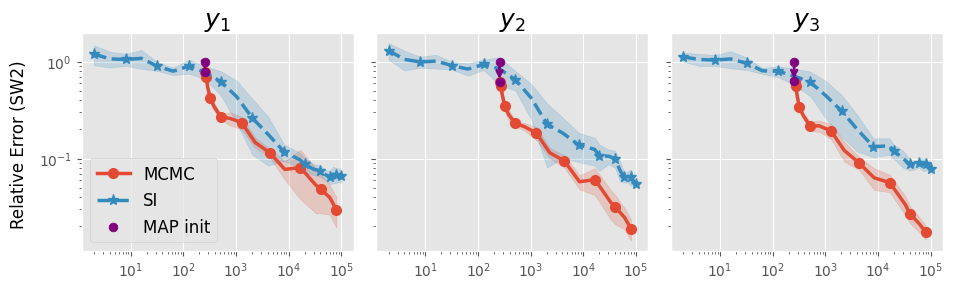

In [18]:
prior_error = 1.0  # error at 2 samples from prior-init chain

# ---- cost conversion ----
si_fme_factor = 1.0
mcmc_step_fme_factor = 2.0  # one h-MALA step ≈ 2 FMEs
si_fme_factor = 1.0
mcmc_fme_factor = 2.0

sample_no_arr = np.array(sample_no_list)
n_mcmc = len(mcmc_main_avg)  # 17 (truncated with [:-6])

# SI x-values: one SI sample = 1 FME
si_x = si_fme_factor * sample_no_arr

nevals_norm = 256
nevals_mod = 256
nevals_rare = 256
nevals_norm_fme = mcmc_fme_factor * nevals_norm
nevals_mod_fme  = mcmc_fme_factor * nevals_mod
nevals_rare_fme = mcmc_fme_factor * nevals_rare

# h-MALA x-values: training cost + 2 FMEs per chain step, over first n_mcmc sample counts
sample_no_arr_mcmc = sample_no_arr[:n_mcmc]
mcmc_x_norm = nevals_norm + mcmc_step_fme_factor * sample_no_arr_mcmc
mcmc_x_mod  = nevals_mod  + mcmc_step_fme_factor * sample_no_arr_mcmc
mcmc_x_rare = nevals_rare + mcmc_step_fme_factor * sample_no_arr_mcmc

lw = 2.5
ms = 7.0

fig, ax = plt.subplots(1, 3, figsize=(9.7, 3.0), sharey=True)

# --- norm (y1) ---
im0_1 = ax[0].plot(
    mcmc_x_norm, mcmc_main_avg,
    marker="o", markevery=2, linewidth=lw, markersize=ms, label="MCMC",
)
im0_2 = ax[0].plot(
    si_x, si_main_avg,
    marker="*", linestyle="dashed", linewidth=lw, markersize=ms+1, markevery=2, label="SI",
)
# ax[0].plot(xs, mc_rate)
ax[0].fill_between(
    mcmc_x_norm,
    mcmc_main_avg - mcmc_main_std,
    mcmc_main_avg + mcmc_main_std,
    color=im0_1[0].get_color(), alpha=0.2,
)
ax[0].fill_between(
    si_x,
    si_main_avg - si_main_std,
    si_main_avg + si_main_std,
    color=im0_2[0].get_color(), alpha=0.2,
)
ax[0].annotate("",
    xy=(nevals_norm, mcmc_main_avg[0]),
    xytext=(nevals_norm, prior_error),
    arrowprops=dict(arrowstyle="->", color="purple", lw=2))
ax[0].scatter([nevals_norm], [prior_error], color="purple", zorder=5, s=40)
ax[0].scatter([nevals_norm], [mcmc_main_avg[0]], color="purple", zorder=5, s=40, label="MAP init")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_title(r"$y_1$", fontsize=18, pad=4)
ax[0].legend(fontsize=12)

# --- mod (y2) ---
im1_1 = ax[1].plot(
    mcmc_x_mod, mcmc_med_avg,
    marker="o", markevery=2, linewidth=lw, markersize=ms,
)
im1_2 = ax[1].plot(
    si_x, si_med_avg,
    marker="*", linestyle="dashed", linewidth=lw, markersize=ms+1, markevery=2,
)
ax[1].fill_between(
    mcmc_x_mod,
    mcmc_med_avg - mcmc_med_std,
    mcmc_med_avg + mcmc_med_std,
    color=im1_1[0].get_color(), alpha=0.2,
)
ax[1].fill_between(
    si_x,
    si_med_avg - si_med_std,
    si_med_avg + si_med_std,
    color=im1_2[0].get_color(), alpha=0.2,
)
ax[1].annotate("",
    xy=(nevals_mod, mcmc_med_avg[0]),
    xytext=(nevals_mod, prior_error),
    arrowprops=dict(arrowstyle="->", color="purple", lw=2))
ax[1].scatter([nevals_mod], [prior_error], color="purple", zorder=5, s=40)
ax[1].scatter([nevals_mod], [mcmc_med_avg[0]], color="purple", zorder=5, s=40)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title(r"$y_2$", fontsize=18, pad=4)

# --- rare (y3) ---
im2_1 = ax[2].plot(
    mcmc_x_rare, mcmc_98_avg,
    marker="o", markevery=2, linewidth=lw, markersize=ms, label="h-MALA",
)
im2_2 = ax[2].plot(
    si_x, si_98_avg,
    marker="*", linestyle="dashed", linewidth=lw, markersize=ms+1, markevery=2, label="SI (ODE)",
)
ax[2].fill_between(
    mcmc_x_rare,
    mcmc_98_avg - mcmc_98_std,
    mcmc_98_avg + mcmc_98_std,
    color=im2_1[0].get_color(), alpha=0.2,
)
ax[2].fill_between(
    si_x,
    si_98_avg - si_98_std,
    si_98_avg + si_98_std,
    color=im2_2[0].get_color(), alpha=0.2,
)
ax[2].annotate("",
    xy=(nevals_rare, mcmc_98_avg[0]),
    xytext=(nevals_rare, prior_error),
    arrowprops=dict(arrowstyle="->", color="purple", lw=2))
ax[2].scatter([nevals_rare], [prior_error], color="purple", zorder=5, s=40)
ax[2].scatter([nevals_rare], [mcmc_98_avg[0]], color="purple", zorder=5, s=40)
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_title(r"$y_3$", fontsize=18, pad=4)

# fig.supxlabel("Forward Model Evaluations (FME-equivalent)")
fig.supylabel("Relative Error (SW2)")

# handles, labels = ax[2].get_legend_handles_labels()
# fig.legend(
#     handles, labels,
#     loc="upper left",
#     ncol=2,
#     frameon=False,
#     fontsize=11.5,
#     handlelength=1.4,
#     handletextpad=0.4,
#     columnspacing=0.8,
#     labelspacing=0.3,
#     borderaxespad=0.2,
# )

plt.tight_layout()
plt.savefig("images/conv_poisson.png", bbox_inches="tight", dpi=300)
plt.show()

In [15]:
import pickle

with open("hyperparam_results/best_hyperparams_low.pkl", "rb") as f:
    low = pickle.load(f)

In [16]:
low

{'hidden_layer': 949,
 'num_hidden_layers': 4,
 'peak_value': 0.0004754575694,
 'weight_decay': 0.0001961654235,
 'interpolant': 'trig_interpolant'}

In [23]:
with open("hyperparam_results/best_hyperparams_mid.pkl", "rb") as f:
    mid = pickle.load(f)

In [24]:
mid

{'hidden_layer': 949,
 'num_hidden_layers': 4,
 'peak_value': 0.0004754575694,
 'weight_decay': 0.0001961654235,
 'interpolant': 'trig_interpolant'}